# Reaching self-consistency: mixing, Kerker, and unstable solutions

Self-consistency is a fixed point, and a root of the residual is the same statement:

$$\rho = F[\rho]
\qquad\Longleftrightarrow\qquad
r[\rho] \equiv F[\rho] - \rho = 0$$

Every notebook before this one reached it by iterating $F$ and damping the iteration. This
one is about what makes that hard and what a different route buys.

**Charge sloshing, and the preconditioner that removes it.** A metal screens: its dielectric
function diverges as $q^{-2}$ at long wavelength, so a small charge imbalance at the scale of
the cell is amplified by the Hartree term from one iteration to the next. Dividing that
divergence out is Kerker preconditioning,

$$\beta \;\longrightarrow\; \beta\,
   \frac{|\mathbf G|^2}{|\mathbf G|^2 + q_{\rm TF}^2},$$

and on an aluminium slab, half metal and half vacuum, it takes the iteration count from
**24 to 14** for one extra transform per iteration.

**Solving $r[\rho] = 0$ as a root instead.** It is not faster, and it does something no mixer
can: it converges on **unstable** self-consistent solutions. Iron's non-magnetic state is a
fixed point of the same equations that damped mixing always slides off, and it is the
reference a magnetic stabilisation energy is quoted against.

In [1]:
from pathlib import Path
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from pypresso import Calculator
from pypresso.scf import Calculation, run_scf

PSEUDO = Path("../tests/data/pseudo")

def load(name):
    return Calculator.from_file(Path("../benchmarks") / name, pseudo_dir=PSEUDO,
                                announce=False, conv_thr=1e-8, max_iterations=200)

aluminium = load("al-slab.in")
slab, slab_pseudos = aluminium.system, aluminium.pseudos
print(f"Al(100), {len(slab.structure.positions)} layers, "
      f"c = {slab.cell.at[2, 2]:.1f} bohr, {slab.kpoints.coords.shape[0]} k-points")

Al(100), 5 layers, c = 31.0 bohr, 3 k-points


## The problem: half the cell screens, half does not

A slab has metal in one half of the cell and vacuum, which screens nothing at all, in the
other. Long-wavelength charge transfer between the two is amplified by exactly the
$q^{-2}$ the metal's screening produces, and the result is charge sloshing back and forth
across the cell, visible in the first few iterations of a plain run.

In [2]:
anderson = aluminium.get_scf()
energies = [h["total_energy"] for h in anderson.history]
print(f"Anderson: {anderson.iterations} iterations, E = {anderson.total_energy:.8f} Ry")
print(f"  worst total energy along the way: {max(energies):+.2f} Ry  "
      f"(the converged one is {anderson.total_energy:.2f})")

Anderson: 24 iterations, E = -20.87908220 Ry
  worst total energy along the way: +105.56 Ry  (the converged one is -20.88)


## Kerker: divide the divergence out

`mixing_mode = 'TF'` damps the long-wavelength components of the residual by the
Thomas-Fermi factor, which is an approximate inverse of the very dielectric response that
causes the sloshing.

Two things about it are physical rather than adjustable. The screening wavevector comes
from the electron density of the cell, $r_s = (3\Omega/4\pi N)^{1/3}$ and
$q_{\rm TF}^2 = (12/\pi)^{2/3}/r_s$, so it is a property of the material; a hand-picked
value over-screens this slab and turns a win into a loss. And only the **charge** channel is
screened, because the magnetization has no $q^{-2}$ divergence to divide out: spin density
is not screened by the Hartree term.

In [3]:
from pypresso.scf.mixing import thomas_fermi_screening

nelec = aluminium.calculation.nelec
q_tf = thomas_fermi_screening(float(slab.cell.volume), nelec) ** 0.5
print(f"q_TF from the cell = {q_tf:.3f} 1/bohr   (a hand-picked 1.5 over-screens by "
      f"{(1.5/q_tf)**2:.1f}x in q^2)")

kerker = aluminium.get_scf(mixing_mode="kerker")
print(f"Anderson          {anderson.iterations:3d} iterations")
print(f"Anderson + Kerker {kerker.iterations:3d} iterations   "
      f"(same answer to {abs(kerker.total_energy - anderson.total_energy):.1e} Ry)")

q_TF from the cell = 1.008 1/bohr   (a hand-picked 1.5 over-screens by 2.2x in q^2)


Anderson           24 iterations
Anderson + Kerker  14 iterations   (same answer to 1.6e-09 Ry)


## The same fixed point, as a root to be found

`scf_solver = 'newton-krylov'` solves $r[\rho] = 0$ instead of iterating $F$. The Jacobian
is never formed, which on even this smallest case would be a $10368 \times 10368$ matrix;
the Krylov solver asks only for its action on a vector.

The figure compares all three on the quantity `conv_thr` measures, the Hartree energy of the
density residual. **The x axis is diagonalisations, not iterations**, which is the only
currency in which a mixer's step and a Krylov step are comparable.

all three agree to 6.2e-08 Ry


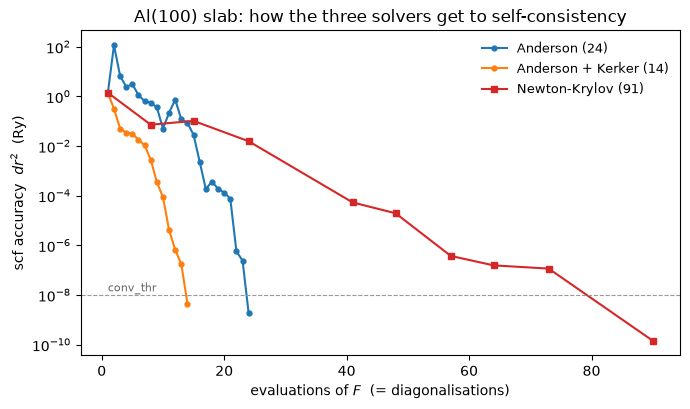

In [4]:
newton = aluminium.get_scf(scf_solver="newton-krylov",
                           scf_solver_options={"forcing": 0.5})

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for label, result, colour in [("Anderson", anderson, "tab:blue"),
                              ("Anderson + Kerker", kerker, "tab:orange")]:
    accuracy = [h["accuracy"] for h in result.history]
    ax.semilogy(np.arange(1, len(accuracy) + 1), accuracy, "o-", ms=3.5,
                color=colour, label=f"{label} ({result.iterations})")
outer = newton.solver.history
ax.semilogy([h["steps"] for h in outer], [h["accuracy"] for h in outer], "s-", ms=4.5,
            color="tab:red", label=f"Newton-Krylov ({newton.solver.steps + newton.iterations})")
ax.axhline(1e-8, color="0.6", lw=0.8, ls="--")
ax.text(1, 1.4e-8, "conv_thr", color="0.4", fontsize=8)
ax.set_xlabel("evaluations of $F$  (= diagonalisations)")
ax.set_ylabel(r"scf accuracy  $dr^2$  (Ry)")
ax.set_title("Al(100) slab: how the three solvers get to self-consistency")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

print(f"all three agree to "
      f"{max(abs(r.total_energy - anderson.total_energy) for r in (kerker, newton)):.1e} Ry")

The outer iteration count of the root-finder is flat, three to six whatever the
conditioning, and that does not help, because each outer step is paid for in inner ones.
Measured over a sweep of vacuum thickness and quoted rather than run:

| vacuum (bohr) | Anderson | Anderson + Kerker | Newton-Krylov |
|---|---|---|---|
| 16 | 24 | **14** | 19 |
| 32 | 34 | **20** | 74 |
| 48 | 32 | **28** | 139 |
| 64 | **35** | 36 | 123 |

On cost the answer is Kerker, and mixing stays the default.

## What a Jacobian is worth: an unstable solution

Iron has two self-consistent solutions at this geometry. The ferromagnetic one is the ground
state; the non-magnetic one is a fixed point of the same equations that damped mixing never
reaches, because mixing is a relaxation and from any magnetic starting point it runs downhill
into the stable solution. A root-finder is stability-blind: it converges on whichever root it
started nearest to. That is how the non-magnetic reference energy of a magnet is obtained
without constraining anything.

Which root is nearest has to be arranged rather than hoped for, so the state is perturbed
away from the symmetric solution and the *same* perturbed state is handed to both solvers.
Doing it that way also measures the size of the basin: a kick of 0.05 decays back to the
non-magnetic state under mixing, 0.20 runs away, and the window where mixing leaves and the
root-finder returns is 0.08 to 0.12. The non-magnetic solution of iron is metastable, not a
sharp saddle.

In [5]:
ferrum = load("fe-unstable.in")
iron, iron_pseudos = ferrum.system, ferrum.pseudos
options = dict(conv_thr=1e-8, max_iterations=200)

# The symmetric root: nothing in the SCF breaks spin symmetry on its own.
calculation = ferrum.calculation
rho = np.asarray(calculation.starting_density())
symmetric = jnp.asarray(np.repeat(rho.mean(axis=0, keepdims=True), rho.shape[0], axis=0))
root = run_scf(iron, iron_pseudos, calculation=Calculation(iron, iron_pseudos), **options,
               starting_density=symmetric)

# Kick it out of its basin, in the direction the instability lives in, and hand the
# *same* perturbed state to both solvers.
shape = rho[0] - rho[1]
shape = shape / np.abs(shape).max()
base = np.asarray(root.density)
kicked = jnp.asarray(np.stack([base[0] + 0.05 * shape, base[1] - 0.05 * shape]))

mixed = run_scf(iron, iron_pseudos, calculation=Calculation(iron, iron_pseudos), **options,
                starting_density=kicked)
saddle = run_scf(iron, iron_pseudos, calculation=Calculation(iron, iron_pseudos), **options,
                 starting_density=kicked, scf_solver="newton-krylov",
                 scf_solver_options={"forcing": 0.5, "gmres_maxiter": 8,
                                     "max_iterations": 12, "kerker": True})

# The check is free and shares nothing with either run above.
reference = load("fe-unstable-nonmagnetic.in").get_scf()

print(f"{'from the same kicked symmetric root':<40} {'E (Ry)':>15} {'m (mu_B)':>10}")
print(f"{'  Anderson, nspin = 2':<40} {mixed.total_energy:15.8f} "
      f"{float(mixed.magnetization):10.4f}")
print(f"{'  Newton-Krylov, nspin = 2':<40} {saddle.total_energy:15.8f} "
      f"{float(saddle.magnetization):10.4f}")
print(f"{'  nspin = 1 (independent reference)':<40} {reference.total_energy:15.8f} "
      f"{'--':>10}")
print(f"\nNewton's root matches the nspin = 1 reference to "
      f"{abs(saddle.total_energy - reference.total_energy):.1e} Ry")
print(f"iron's magnetic stabilisation energy = "
      f"{1000 * (saddle.total_energy - mixed.total_energy):.1f} mRy")

from the same kicked symmetric root               E (Ry)   m (mu_B)
  Anderson, nspin = 2                       -55.44642602     3.4052
  Newton-Krylov, nspin = 2                  -55.38228995     0.0002
  nspin = 1 (independent reference)         -55.38228995         --

Newton's root matches the nspin = 1 reference to 1.6e-09 Ry
iron's magnetic stabilisation energy = 64.1 mRy


With the preconditioner switched off the same solver from the same starting state also
converges, reports an accuracy below `conv_thr`, and lands on the *ferromagnetic* solution
instead. A poorly conditioned inner solve degrades the step towards a damped mixing step,
and a mixing step flows to the stable root. On a problem with more than one solution the
preconditioner decides which physics comes out, and both answers look equally converged.

## The same thing with DFT+U

The occupation matrix of the Hubbard shell is a variable of the SCF in its own right, mixed
alongside the density, so a root-finder solves for it on the same footing.

DFT+U has an unstable solution of its own, and reaching it takes more than an unpolarised
density: the occupation matrix is filled by Hund's rule at the start, so the majority and
minority $d$ orbitals begin unequal whatever the starting magnetization is, and a polarised
occupation matrix regenerates the Hubbard potential that undoes a kick to the density alone.
Starting from a uniform occupation matrix instead is what puts the run near the symmetric
solution.

The test is the definition of an unstable fixed point: perturb it, and see which solver
comes back.

In [7]:
from pypresso.hubbard import uniform_ns

nickel_calc = load("ni-u-unstable.in")
nickel, nickel_pseudos = nickel_calc.system, nickel_calc.pseudos
setup = nickel_calc.calculation
print("init_ns eigenvalues per spin (Hund's rule):",
      *[np.round(np.linalg.eigvalsh(np.asarray(setup.starting_ns())[s, 0]), 2)
        for s in range(2)])

# The saddle: a spin-symmetric density and an orbitally uniform ns.
rho = np.asarray(setup.starting_density())
start = dict(starting_density=jnp.asarray(np.repeat(rho.mean(0, keepdims=True), 2, axis=0)),
             starting_becsum=setup.starting_becsum(),
             starting_ns=uniform_ns(setup.hubbard, setup.nspin))
saddle = run_scf(nickel, nickel_pseudos, calculation=Calculation(nickel, nickel_pseudos),
                 conv_thr=1e-9, max_iterations=150, **start)
print(f"the saddle:  E = {saddle.total_energy:.8f} Ry   m = {float(saddle.magnetization):+.6f}")

# Kick it 2% along the magnetization direction, in both rho and ns.
scale = np.array([1.02, 0.98])[:, None, None, None]
kicked = dict(starting_density=jnp.asarray(np.asarray(saddle.density) * scale),
              starting_becsum=setup.starting_becsum(),
              starting_ns=jnp.asarray(np.asarray(saddle.ns) * scale))

away = run_scf(nickel, nickel_pseudos, calculation=Calculation(nickel, nickel_pseudos),
               conv_thr=1e-9, max_iterations=150, **kicked)
back = run_scf(nickel, nickel_pseudos, calculation=Calculation(nickel, nickel_pseudos),
               conv_thr=1e-9, max_iterations=150, scf_solver="newton-krylov",
               scf_solver_options={"forcing": 0.1, "gmres_maxiter": 30, "max_iterations": 15},
               **kicked)
print(f"{'from the perturbed saddle':<28} {'E (Ry)':>15} {'m (mu_B)':>11}")
print(f"{'  Anderson (runs away)':<28} {away.total_energy:15.8f} {float(away.magnetization):11.6f}")
print(f"{'  Newton-Krylov (returns)':<28} {back.total_energy:15.8f} {float(back.magnetization):11.6f}")


init_ns eigenvalues per spin (Hund's rule): [1. 1. 1. 1. 1.] [0.8 0.8 0.8 0.8 0.8]


the saddle:  E = -86.20620046 Ry   m = +0.000000


from the perturbed saddle             E (Ry)    m (mu_B)
  Anderson (runs away)          -86.41841670    2.000000
  Newton-Krylov (returns)       -86.20620046    0.000005


Mixing amplifies the kick into the ferromagnet, which is what makes the state unstable, and
the root-finder puts it back.

One caveat. Started *far* from the symmetric solution, which root the search finds depends
on the inner-solve accuracy in no systematic way: three settings gave the ferromagnet, a
third solution at $m = -0.34$, and the ferromagnet again, all converged and all reporting an
accuracy below `conv_thr`. On a problem with several solutions it is the starting state that
selects one, not the solver's tuning.

---
The tests behind this notebook: `tests/regression/test_scf_solvers.py`,
`tests/unit/test_fermi_response.py`.